<a href="https://colab.research.google.com/github/w-olivine29/data-analysis/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_5%EA%B0%95_%EC%8B%A4%EC%8A%B5_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%A0%80%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 오픈소스 기반 데이터 분석 5강 - 데이터 저장

In [ ]:
#💡 실습 전 확인

파일 업로드하기: 실행 전 좌측 파일 메뉴(📁)에 실습에서 제공되는 Chapter 3 파일들을 반드시 업로드하기

주의사항: 런타임 연결이 끊기거나 세션이 종료되면 가상머신이 초기화되어 파일이 삭제되므로, 재접속 시 다시 업로드하기

## 5-1 CSV 형식 저장

In [2]:
import pandas as pd

data = {
    'student_id': [101, 102, 103, 104, 105],
    'database_score': [85, 76, 92, 63, 88],
    'cloudcomputing_score': [78, 82, 95, 70, 84],
    'python_score': [92, 78, 85, 75, 91],
    'watch_rate': [0.95, 0.87, 0.99, 0.80, 0.93]
}
## DataFrame 생성
df = pd.DataFrame(data)
print(df)

## CSV 형식으로 저장
df.to_csv("student_analysis.csv", encoding= "utf-8", index = False)


   student_id  database_score  cloudcomputing_score  python_score  watch_rate
0         101              85                    78            92        0.95
1         102              76                    82            78        0.87
2         103              92                    95            85        0.99
3         104              63                    70            75        0.80
4         105              88                    84            91        0.93


## 5-2 JSON 형식 저장

In [19]:
from textwrap import indent
from ast import dump
### 라이브러리 임포트
import json
import pandas as pd

data = {
    "이름": "홍길동",
    "나이": 25,
    "거주지": "서울",
    "관심사": ["프로그래밍", "데이터 분석", "여행"]
}

## 1.json.dump를 이용한 저장
### 가독성을 위해 indent 설정 (들여쓰기)
### json은 아스키코드만 저장하게끔 기본설정이 돼있기에 한글을 저장하게끔 관련 설정을 False
with open("output.json", mode="w", encoding="utf-8") as f:
    json.dump(data, f, indent = 4, ensure_ascii = False)


## 2.DataFrame을 이용한 저장

# df = pd.DataFrame(data)
df = pd.DataFrame([data])
df.to_json("output_df.json") #별도 설정없이 그냥 저장해보기
df.to_json("output_df_2.json", orient = "records",indent = 4, force_ascii = False)
df.to_json("output_df_3.json", orient = "columns",indent = 4, force_ascii = False)



data가 위 예제와 같이 단일 딕셔너리 형태일 때, data로 넘기는 것과 [data]로 넘기는 것은 데이터를 '하나의 행(Row)'으로 볼 것인지, 아니면 '값들의 나열'로 볼 것인지에서 근본적인 차이가 발생

## 5-3 Pandas Dataframe 데이터 추출

In [36]:
import pandas as pd

data = {
    "이름": ["김철수", "이영희", "박민수", "최지훈", "정소희"],
    "학년": [1, 2, 3, 4, 2],
    "학점": [4.2, 3.8, 4.5, 3.9, 3.5],
    "학과": ["컴퓨터학", "경영학", "농학", "교육학", "영어영문학"],
    "동아리": ["프로그래밍", "독서토론", "로봇공학", "봉사활동", "음악감상"]
}


# df = pd.DataFrame([data]
df = pd.DataFrame(data)
print(df)

## DataFrame 인덱스 출력
print("\n== DataFrame 인덱스 출력 ==")
print(df.index)

## DataFrame 컬럼 출력
print("\n== DataFrame 컬럼 출력 ==")
print(df.columns)

## DataFrame 행 출력
print("\n== DataFrame 행 출력 ==")
print(df.values) # NumPy 2차원 배열(ndarray) 형태로 반환
print("\n",df.values.tolist())  # 파이썬 순수 2차원 리스트(list) 형태로 변환


## DataFrame 값 출력
print("\n== DataFrame 값 출력 ==")
print(df.values.flatten())


    이름  학년   학점     학과    동아리
0  김철수   1  4.2   컴퓨터학  프로그래밍
1  이영희   2  3.8    경영학   독서토론
2  박민수   3  4.5     농학   로봇공학
3  최지훈   4  3.9    교육학   봉사활동
4  정소희   2  3.5  영어영문학   음악감상

== DataFrame 인덱스 출력 ==
RangeIndex(start=0, stop=5, step=1)

== DataFrame 컬럼 출력 ==
Index(['이름', '학년', '학점', '학과', '동아리'], dtype='object')

== DataFrame 행 출력 ==
[['김철수' 1 4.2 '컴퓨터학' '프로그래밍']
 ['이영희' 2 3.8 '경영학' '독서토론']
 ['박민수' 3 4.5 '농학' '로봇공학']
 ['최지훈' 4 3.9 '교육학' '봉사활동']
 ['정소희' 2 3.5 '영어영문학' '음악감상']]

 [['김철수', 1, 4.2, '컴퓨터학', '프로그래밍'], ['이영희', 2, 3.8, '경영학', '독서토론'], ['박민수', 3, 4.5, '농학', '로봇공학'], ['최지훈', 4, 3.9, '교육학', '봉사활동'], ['정소희', 2, 3.5, '영어영문학', '음악감상']]

== DataFrame 값 출력 ==
['김철수' 1 4.2 '컴퓨터학' '프로그래밍' '이영희' 2 3.8 '경영학' '독서토론' '박민수' 3 4.5 '농학'
 '로봇공학' '최지훈' 4 3.9 '교육학' '봉사활동' '정소희' 2 3.5 '영어영문학' '음악감상']


## 5-4 DataFrame 생성 방법

In [39]:
import pandas as pd
import json

data = {
    "이름": ["김철수", "이영희", "박민수", "최지훈", "정소희"],
    "학년": [1, 2, 3, 4, 2],
    "학점": [4.2, 3.8, 4.5, 3.9, 3.5],
    "학과": ["컴퓨터공학", "경영학", "전자공학", "의학", "심리학"],
    "동아리": ["프로그래밍", "독서토론", "로봇공학", "봉사활동", "음악감상"]
}

## 딕셔너리, csv, json으로 부터 DataFrame 생성
df1 = pd.DataFrame.from_dict(data)
df2 = pd.read_csv("students.csv")
df3 = pd.read_json("students.json")

## 세가지 방법 결과 비교
print(df1.shape)
print(df2.shape)
print(df3.shape)



(5, 5)
(5, 5)
(5, 5)


## 5-5 DataFrame 저장 방법

In [43]:
import pandas as pd

data = {
    "이름": ["김철수", "이영희", "박민수", "최지훈", "정소희"],
    "학년": [1, 2, 3, 4, 2],
    "학점": [4.2, 3.8, 4.5, 3.9, 3.5],
    "학과": ["컴퓨터공학", "경영학", "전자공학", "의학", "심리학"],
    "동아리": ["프로그래밍", "독서토론", "로봇공학", "봉사활동", "음악감상"]
}

## Dataframe 생성
df = pd.DataFrame.from_dict(data)

## CSV, JSON 형식으로 저장
df.to_csv("student_scores.csv")
df.to_json("student_scores.json", force_ascii= False)

## HTML 형식으로 저장
html_table = df.to_html()
print(html_table)

with open("student_scores.html", mode= "w") as f:
    f.write(html_table)


<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>이름</th>
      <th>학년</th>
      <th>학점</th>
      <th>학과</th>
      <th>동아리</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>김철수</td>
      <td>1</td>
      <td>4.2</td>
      <td>컴퓨터공학</td>
      <td>프로그래밍</td>
    </tr>
    <tr>
      <th>1</th>
      <td>이영희</td>
      <td>2</td>
      <td>3.8</td>
      <td>경영학</td>
      <td>독서토론</td>
    </tr>
    <tr>
      <th>2</th>
      <td>박민수</td>
      <td>3</td>
      <td>4.5</td>
      <td>전자공학</td>
      <td>로봇공학</td>
    </tr>
    <tr>
      <th>3</th>
      <td>최지훈</td>
      <td>4</td>
      <td>3.9</td>
      <td>의학</td>
      <td>봉사활동</td>
    </tr>
    <tr>
      <th>4</th>
      <td>정소희</td>
      <td>2</td>
      <td>3.5</td>
      <td>심리학</td>
      <td>음악감상</td>
    </tr>
  </tbody>
</table>


## 5-6 실습 시나리오

## 데이터 수집

In [58]:
import requests

url = "http://apis.data.go.kr/B552584/ArpltnInforInqireSvc/getCtprvnRltmMesureDnsty"
api_key = ''

params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '5',
    'pageNo': '1',
    'sidoName': '서울',
    'ver': '1.0'
}

## 데이터 수집
response = requests.get(url, params=params)

## 호출 성공/실패 출력
print(response.json())

{'response': {'body': {'totalCount': 40, 'items': [{'so2Grade': '1', 'coFlag': None, 'khaiValue': '75', 'so2Value': '0.003', 'coValue': '0.3', 'pm25Flag': None, 'pm10Flag': None, 'o3Grade': '2', 'pm10Value': '19', 'khaiGrade': '2', 'pm25Value': '11', 'sidoName': '서울', 'no2Flag': None, 'no2Grade': '1', 'o3Flag': None, 'pm25Grade': '1', 'so2Flag': None, 'dataTime': '2026-09-30 21:00', 'coGrade': '1', 'no2Value': '0.007', 'stationName': '강남구', 'pm10Grade': '1', 'o3Value': '0.060'}, {'so2Grade': '1', 'coFlag': None, 'khaiValue': '72', 'so2Value': '0.003', 'coValue': '0.3', 'pm25Flag': None, 'pm10Flag': None, 'o3Grade': '2', 'pm10Value': '14', 'khaiGrade': '2', 'pm25Value': '6', 'sidoName': '서울', 'no2Flag': None, 'no2Grade': '1', 'o3Flag': None, 'pm25Grade': '1', 'so2Flag': None, 'dataTime': '2026-09-30 21:00', 'coGrade': '1', 'no2Value': '0.008', 'stationName': '서초구', 'pm10Grade': '1', 'o3Value': '0.056'}, {'so2Grade': '1', 'coFlag': None, 'khaiValue': '68', 'so2Value': '0.003', 'coValue':


1개만 요청한 결과

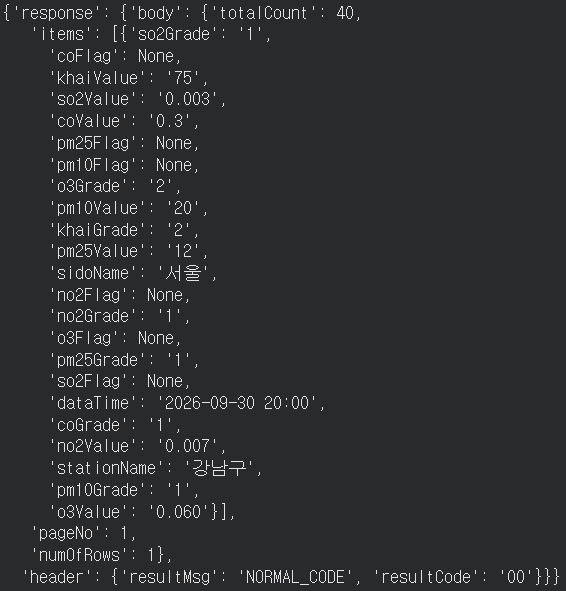

## 데이터 프레임 생성

In [68]:
import pandas as pd

## requests로부터 response, body, item 항목 읽기
data = response.json()["response"]["body"]["items"]

print("type:", type(data))
print("len:",len(data))
print("data[0]:",data[0]) # 리스트로 받아진 data의 0번 인덱스 요소 가져오기

print()
df = pd.DataFrame(data)

print("pm25Grade 컬럼 가져오기")
print(df["pm25Grade"]) #특정 컬럼만 가져오기


type: <class 'list'>
len: 5
data[0]: {'so2Grade': '1', 'coFlag': None, 'khaiValue': '75', 'so2Value': '0.003', 'coValue': '0.3', 'pm25Flag': None, 'pm10Flag': None, 'o3Grade': '2', 'pm10Value': '19', 'khaiGrade': '2', 'pm25Value': '11', 'sidoName': '서울', 'no2Flag': None, 'no2Grade': '1', 'o3Flag': None, 'pm25Grade': '1', 'so2Flag': None, 'dataTime': '2026-09-30 21:00', 'coGrade': '1', 'no2Value': '0.007', 'stationName': '강남구', 'pm10Grade': '1', 'o3Value': '0.060'}

pm25Grade 컬럼
0    1
1    1
2    2
3    1
4    1
Name: pm25Grade, dtype: object


## 다양항 형식으로 데이터 저장


In [71]:
## CSV 형식 데이터 저장
df.to_csv('air_pollution.csv', index=False, encoding='utf-8')

## JSON 형식 데이터 저장
df.to_json('air_pollution.json', indent = 4, force_ascii= False)

## EXCEL 형식 데이터 저장
df.to_excel('air_pollution.xlsx', index = False)

## HTML 형식 데이터 저장
df.to_html("air_pollution.html")